In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import rlcard
import numpy as np
from agents.models import TienLenNet, TienLenLSTMNet
from agents.agents import HeuristicSearchAgent, TienLenRandomAgent, TrainedDenseAgent, TrainedLSTMAgent, NaiveTienLenAgent
from rlcard.envs.registration import register
from rlcard.agents.dmc_agent.model import DMCModel
from rlcard.utils import tournament
import random
import matplotlib.pyplot as plt

In [2]:
register(env_id='tien-len', entry_point='envs.tienlen_env:TienLenEnv')
env = rlcard.make('tien-len')


In [4]:
use_accel = torch.accelerator.is_available()
seed = 1
lr = 1e-4
model = 'dense'

torch.manual_seed(seed)

if use_accel:
    device = torch.accelerator.current_accelerator()
else:
    device = torch.device("cpu")


In [5]:
class DenseReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, obs, action, payoff):
        """
        obs: Snapshot feature vector (159,)
        action: Action feature vector (67,)
        payoff: Final game reward (scalar)
        """
        self.buffer.append((
            torch.as_tensor(obs, dtype=torch.float32),
            torch.as_tensor(action, dtype=torch.float32),
            torch.as_tensor([payoff], dtype=torch.float32)
        ))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, min(len(self.buffer), batch_size))
        obses, actions, payoffs = zip(*samples)
        return (torch.stack(obses),
                torch.stack(actions),
                torch.stack(payoffs))

    def __len__(self):
        return len(self.buffer)

class LSTMReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, history, obs, action, payoff):
        self.buffer.append((history, obs, action, payoff))

    def sample(self, batch_size):
        samples = random.sample(self.buffer, min(len(self.buffer), batch_size))
        histories, obses, actions, payoffs = zip(*samples)
        return (torch.stack(histories),
                torch.stack(obses),
                torch.stack(actions),
                torch.stack(payoffs))

    def __len__(self):
        return len(self.buffer)

In [7]:
def train_LSTM_iteration(model, optimizer, buffer, batch_size=512, episodes_per_step=10):
    model.train()
    # Data Collection
    for _ in range(episodes_per_step):
        state, player_id = env.reset()
        episode_data = []

        while not env.is_over():
            legal_actions = state['legal_actions']
            num_legal = len(legal_actions)

            # Prepare inputs for scoring
            obs_t = torch.FloatTensor(state['obs']).unsqueeze(0).repeat(num_legal, 1)
            hist_t = torch.FloatTensor(state['history']).unsqueeze(0).repeat(num_legal, 1, 1)
            act_list = list(legal_actions.keys())
            act_feats = torch.FloatTensor(np.array(list(legal_actions.values())))

            with torch.no_grad():
                q_values = model(hist_t, obs_t, act_feats).squeeze(-1)
                if random.random() < 0.1:
                    idx = random.randrange(num_legal)
                else:
                    idx = torch.argmax(q_values).item()

            chosen_action = act_list[idx]
            episode_data.append({
                'player_id': player_id,
                'history': torch.FloatTensor(state['history']),
                'obs': torch.FloatTensor(state['obs']),
                'act': torch.FloatTensor(legal_actions[chosen_action])
            })

            state, player_id = env.step(chosen_action)
        final_payoffs = env.get_payoffs()
        for d in episode_data:
            buffer.push(d['history'], d['obs'], d['act'], torch.FloatTensor([final_payoffs[d['player_id']]]))

    # Model Update
    if len(buffer) < batch_size:
        return 0

    hist_b, obs_b, act_b, target_b = buffer.sample(batch_size)

    optimizer.zero_grad()
    predictions = model(hist_b, obs_b, act_b)
    loss = torch.nn.MSELoss()(predictions, target_b)
    loss.backward()
    optimizer.step()

    return loss.item()

def train_dense_iteration(model, optimizer, buffer, batch_size=512, episodes_per_step=10):
    model.train()

    # Data Collection
    for _ in range(episodes_per_step):
        state, player_id = env.reset()
        episode_data = []

        while not env.is_over():
            legal_actions = state['legal_actions']
            num_legal = len(legal_actions)

            obs_t = torch.FloatTensor(state['obs']).unsqueeze(0).repeat(num_legal, 1)
            act_list = list(legal_actions.keys())
            act_feats = torch.FloatTensor(np.array(list(legal_actions.values())))

            with torch.no_grad():
                q_values = model(obs_t, act_feats).squeeze(-1)
                idx = torch.argmax(q_values).item() if random.random() > 0.1 else random.randrange(num_legal)

            chosen_action = act_list[idx]
            episode_data.append({
                'player_id': player_id,
                'obs': torch.FloatTensor(state['obs']),
                'act': torch.FloatTensor(legal_actions[chosen_action])
            })
            state, player_id = env.step(chosen_action)

        final_payoffs = env.get_payoffs()
        for d in episode_data:
            buffer.push(d['obs'], d['act'], torch.FloatTensor([final_payoffs[d['player_id']]]))

    # Update Model
    if len(buffer) < batch_size: return 0
    obs_b, act_b, target_b = buffer.sample(batch_size)

    optimizer.zero_grad()
    predictions = model(obs_b, act_b)
    loss = torch.nn.MSELoss()(predictions, target_b)
    loss.backward()
    optimizer.step()

    return loss.item()


def train_teacher_student(model, teacher, buffer, optimizer, criterion, episodes=20):
    model.train()
    total_loss = 0
    games_processed = 0
    teacher_matches = 0
    total_steps = 0

    for ep in range(episodes):
        state, player_id = env.reset()
        episode_data = []

        while not env.is_over():
            total_steps += 1
            teacher_move = teacher.step(state)

            obs_t = torch.FloatTensor(state['obs']).unsqueeze(0)
            act_list = list(state['legal_actions'].keys())
            act_feats = torch.FloatTensor(np.array(list(state['legal_actions'].values())))

            with torch.no_grad():
                q_values = model(obs_t.repeat(len(act_list), 1), act_feats).squeeze(-1)
                model_move = act_list[torch.argmax(q_values).item()]

            if model_move == teacher_move:
                teacher_matches += 1

            if teacher_move not in state['legal_actions']:
                teacher_move = random.choice(act_list)

            action_feat = state['legal_actions'][teacher_move]

            episode_data.append({
                'player_id': player_id,
                'obs': state['obs'],
                'act': action_feat
            })

            state, player_id = env.step(teacher_move)

        payoffs = env.get_payoffs()
        for d in episode_data:
            buffer.push(d['obs'], d['act'], payoffs[d['player_id']])

        games_processed += 1

    if len(buffer) > 512:
        obs_b, act_b, target_b = buffer.sample(512)

        optimizer.zero_grad()
        predictions = model(obs_b, act_b)
        loss = criterion(predictions, target_b)
        loss.backward()
        optimizer.step()
        total_loss = loss.item()

    accuracy = (teacher_matches / total_steps) * 100 if total_steps > 0 else 0
    return total_loss, accuracy

def load_model():
    env = rlcard.make('tien-len')
    model = DMCModel(env.state_shape, [52])
    checkpoint = torch.load('models/rl-tien-len/model.tar', map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    return TrainedAgent(model)


def evaluate(trained_agent, num=10):
    env = rlcard.make('tien-len')
    env.set_agents([trained_agent, NaiveTienLenAgent(), NaiveTienLenAgent(), NaiveTienLenAgent()])
    results = tournament(env, num)
    print(f"Tournament Results (Avg Payoffs): {results}")

def evaluate_with_winrates(trained_agent, num_games=1000):
    env = rlcard.make('tien-len')
    agents = [trained_agent, NaiveTienLenAgent(), NaiveTienLenAgent(), NaiveTienLenAgent()]
    wins = [0] * 4
    payoffs_sum = [0.0] * 4
    for _ in range(num_games):
        env.set_agents(agents)
        state, player_id = env.reset()
        while not env.is_over():
            agent = env.agents[player_id]
            action, _ = agent.eval_step(state)
            state, player_id = env.step(action)
        payoffs = env.get_payoffs()
        for i in range(4):
            payoffs_sum[i] += payoffs[i]
        # Highest payoff = first to finish (gets +1 for each player who finishes after them)
        winner = max(range(4), key=lambda i: payoffs[i])
        wins[winner] += 1
    for i in range(4):
        print(f"Player {i}: Win Rate = {wins[i]/num_games:.1%}, "
              f"Avg Payoff = {payoffs_sum[i]/num_games:.3f}")

    return {
        'winrates': [wins[i]/num_games for i in range(4)],
        'avg_payoffs': [payoffs_sum[i]/num_games for i in range(4)]
    }


def play_test_game(trained_agent):
    env = rlcard.make('tien-len')
    env.set_agents([trained_agent, NaiveTienLenAgent(), HeuristicSearchAgent(env.game.judger), TienLenRandomAgent()])

    state, player_id = env.reset()
    print("--- Game Start ---")

    while not env.is_over():
        current_agent = env.agents[player_id]
        action, _ = current_agent.eval_step(state)

        move_desc = action if action else "PASS"
        print(f"Player {player_id} plays: {move_desc}")
        state, player_id = env.step(action)

    print("--- Game Over ---")
    print(f"Final Payoffs: {env.get_payoffs()}")


In [8]:
if model == 'dense':
    model = TienLenNet(env.state_shape[0], [67])
    buffer = DenseReplayBuffer(capacity=10000)
    train_iteration = train_dense_iteration
    TrainedAgent = TrainedDenseAgent
else:
    model = TienLenLSTMNet(state_dim=159, action_dim=67)
    buffer = LSTMReplayBuffer(capacity=10000)
    train_iteration = train_LSTM_iteration
    TrainedAgent = TrainedLSTMAgent


optimizer = optim.AdamW(model.parameters(), lr=lr)
criterion = nn.MSELoss()


In [9]:
teacher = HeuristicSearchAgent(env.game.judger)
for i in range(10):
    loss, acc = train_teacher_student(model, teacher, buffer, optimizer, criterion)
    if i % 2 == 0:
        print(f">>> SESSION UPDATE | Iteration: {i} | Teacher Sync: {acc:.1f}%")
        torch.save(model.state_dict(), f"models/tienlen_dense_teacher_{i}.pth")

>>> SESSION UPDATE | Iteration: 0 | Teacher Sync: 57.8%
>>> SESSION UPDATE | Iteration: 2 | Teacher Sync: 58.8%
>>> SESSION UPDATE | Iteration: 4 | Teacher Sync: 61.1%
>>> SESSION UPDATE | Iteration: 6 | Teacher Sync: 63.3%
>>> SESSION UPDATE | Iteration: 8 | Teacher Sync: 63.0%


In [10]:
loss_history = []          # Every iteration: (iteration, loss)
eval_history = []          # Every 250 iters: (iteration, eval_results)

TOTAL_ITERS = 3001
EVAL_INTERVAL = 250
EVAL_GAMES = 1500

In [11]:
for i in range(TOTAL_ITERS):
    loss = train_iteration(model, optimizer, buffer)
    loss_history.append((i, loss))
    if i % EVAL_INTERVAL == 0 or i == TOTAL_ITERS - 1:
        agent = TrainedAgent(model)
        results = evaluate_with_winrates(agent, num_games=EVAL_GAMES)
        eval_history.append((i, results))
        print(f"Iteration {i}, Loss: {loss:.4f}")
        print(f"  Win Rates: {[f'{w:.1%}' for w in results['winrates']]}")
        print(f"  Avg Payoffs: {[f'{p:.3f}' for p in results['avg_payoffs']]}")

import pickle
with open('metrics.pkl', 'wb') as f:
    pickle.dump({
        'loss_history': loss_history,
        'eval_history': eval_history
    }, f)
print("Metrics saved to metrics.pkl")


Player 0: Win Rate = 7.6%, Avg Payoff = 0.764
Player 1: Win Rate = 28.7%, Avg Payoff = 1.582
Player 2: Win Rate = 31.2%, Avg Payoff = 1.782
Player 3: Win Rate = 32.5%, Avg Payoff = 1.839
Iteration 0, Loss: 2.1659
  Win Rates: ['7.6%', '28.7%', '31.2%', '32.5%']
  Avg Payoffs: ['0.764', '1.582', '1.782', '1.839']
Player 0: Win Rate = 30.3%, Avg Payoff = 1.727
Player 1: Win Rate = 23.8%, Avg Payoff = 1.465
Player 2: Win Rate = 23.1%, Avg Payoff = 1.427
Player 3: Win Rate = 22.7%, Avg Payoff = 1.378
Iteration 250, Loss: 0.7869
  Win Rates: ['30.3%', '23.8%', '23.1%', '22.7%']
  Avg Payoffs: ['1.727', '1.465', '1.427', '1.378']
Player 0: Win Rate = 29.4%, Avg Payoff = 1.725
Player 1: Win Rate = 27.5%, Avg Payoff = 1.546
Player 2: Win Rate = 23.0%, Avg Payoff = 1.408
Player 3: Win Rate = 20.1%, Avg Payoff = 1.319
Iteration 500, Loss: 0.8776
  Win Rates: ['29.4%', '27.5%', '23.0%', '20.1%']
  Avg Payoffs: ['1.725', '1.546', '1.408', '1.319']
Player 0: Win Rate = 34.4%, Avg Payoff = 1.859
Pla

In [13]:
agent = TrainedAgent(model)
evaluate_with_winrates(agent,4000)

Player 0: Win Rate = 36.6%, Avg Payoff = 1.937
Player 1: Win Rate = 23.6%, Avg Payoff = 1.466
Player 2: Win Rate = 20.8%, Avg Payoff = 1.343
Player 3: Win Rate = 19.1%, Avg Payoff = 1.254


{'winrates': [0.36575, 0.236, 0.20775, 0.1905],
 'avg_payoffs': [np.float64(1.93725),
  np.float64(1.466125),
  np.float64(1.3425),
  np.float64(1.253625)]}

In [14]:
play_test_game(agent)

--- Game Start ---
Player 1 plays: ((3, 0),)
Player 2 plays: ((3, 1),)
Player 3 plays: ((10, 0),)
Player 0 plays: ((10, 2),)
Player 1 plays: ((11, 3),)
Player 2 plays: ((13, 0),)
Player 3 plays: ((15, 1),)
Player 0 plays: ((15, 3),)
Player 1 plays: PASS
Player 2 plays: PASS
Player 3 plays: PASS
Player 0 plays: ((3, 2), (4, 1), (5, 1))
Player 1 plays: ((5, 3), (6, 2), (7, 1))
Player 2 plays: ((9, 2), (10, 3), (11, 0))
Player 3 plays: PASS
Player 0 plays: PASS
Player 1 plays: ((11, 1), (12, 0), (13, 3))
Player 2 plays: ((12, 1), (13, 2), (14, 1))
Player 1 plays: PASS
Player 2 plays: ((5, 2), (6, 0), (7, 0))
Player 3 plays: ((8, 2), (9, 1), (10, 1))
Player 0 plays: PASS
Player 1 plays: PASS
Player 2 plays: PASS
Player 3 plays: ((8, 1),)
Player 0 plays: ((9, 0),)
Player 1 plays: ((11, 2),)
Player 2 plays: PASS
Player 3 plays: ((13, 1),)
Player 0 plays: PASS
Player 1 plays: ((15, 2),)
Player 3 plays: PASS
Player 1 plays: ((5, 0),)
Player 2 plays: ((9, 3),)
Player 3 plays: PASS
Player 0 play

In [15]:
with open('metrics.pkl', 'rb') as f:
    metrics = pickle.load(f)
    loss_history = metrics['loss_history']
    eval_history = metrics['eval_history']

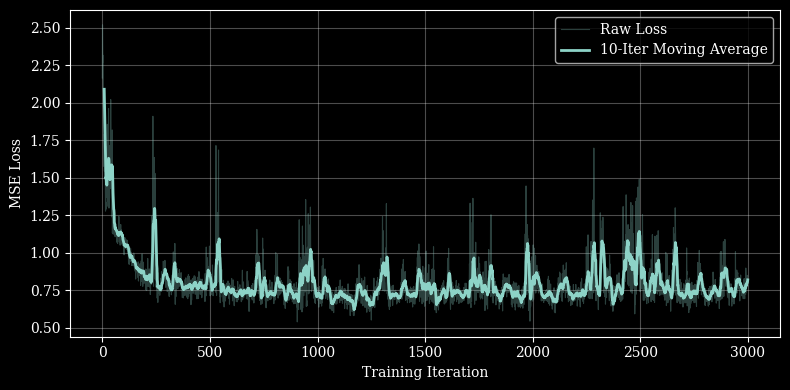

In [16]:
if 'loss_history' not in globals():
    with open('metrics.pkl', 'rb') as f:
        metrics = pickle.load(f)
        loss_history = metrics['loss_history']
iters = [x[0] for x in loss_history]
losses = [x[1] for x in loss_history]
plt.rcParams['savefig.transparent'] = True
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(8, 4))
# Raw loss (thin, light)
ax.plot(iters, losses, alpha=0.3, linewidth=0.8, label='Raw Loss')
# 10-iteration SMA
window = 10
sma = np.convolve(losses, np.ones(window)/window, mode='valid')
sma_iters = iters[window-1:]
ax.plot(sma_iters, sma, linewidth=2, color='C0', label=f'{window}-Iter Moving Average')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('MSE Loss')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('loss_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

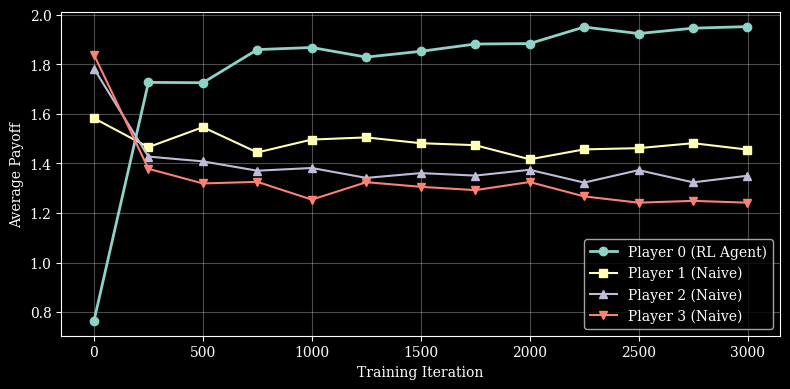

In [19]:
if 'eval_history' not in globals():
    with open('metrics.pkl', 'rb') as f:
        metrics = pickle.load(f)
        eval_history = metrics['eval_history']

checkpoints = [x[0] for x in eval_history]
payoffs = {i: [x[1]['avg_payoffs'][i] for x in eval_history] for i in range(4)}
plt.rcParams['savefig.transparent'] = True
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(checkpoints, payoffs[0], marker='o', linewidth=2, label='Player 0 (RL Agent)')
ax.plot(checkpoints, payoffs[1], marker='s', linewidth=1.5, label='Player 1 (Naive)')
ax.plot(checkpoints, payoffs[2], marker='^', linewidth=1.5, label='Player 2 (Naive)')
ax.plot(checkpoints, payoffs[3], marker='v', linewidth=1.5, label='Player 3 (Naive)')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Average Payoff')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('payoff_progression.pdf', format='pdf', bbox_inches='tight')
plt.show()

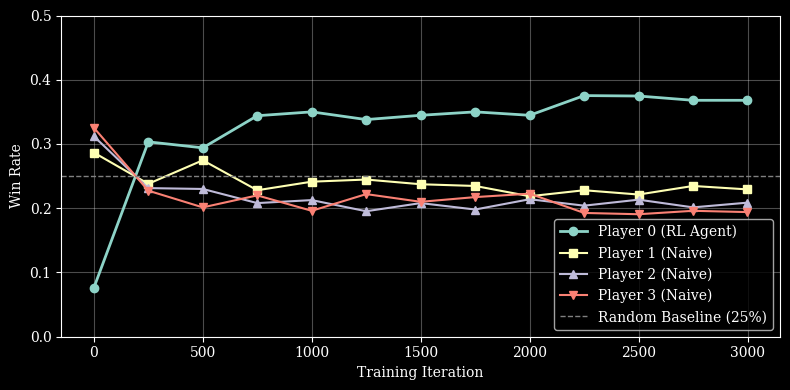

In [22]:
if 'eval_history' not in globals():
    with open('metrics.pkl', 'rb') as f:
        metrics = pickle.load(f)
        eval_history = metrics['eval_history']

checkpoints = [x[0] for x in eval_history]
winrates = {i: [x[1]['winrates'][i] for x in eval_history] for i in range(4)}
plt.rcParams['savefig.transparent'] = True
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(checkpoints, winrates[0], marker='o', linewidth=2, label='Player 0 (RL Agent)')
ax.plot(checkpoints, winrates[1], marker='s', linewidth=1.5, label='Player 1 (Naive)')
ax.plot(checkpoints, winrates[2], marker='^', linewidth=1.5, label='Player 2 (Naive)')
ax.plot(checkpoints, winrates[3], marker='v', linewidth=1.5, label='Player 3 (Naive)')
ax.axhline(y=0.25, color='gray', linestyle='--', linewidth=1, label='Random Baseline (25%)')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Win Rate')
ax.set_ylim(0, 0.50)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('winrate_progression.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [23]:
def evaluate_with_winrates(trained_agent, num_games=1000):
    env = rlcard.make('tien-len')
    agents = [HeuristicSearchAgent(env.game.judger), NaiveTienLenAgent(), NaiveTienLenAgent(), NaiveTienLenAgent()]
    wins = [0] * 4
    payoffs_sum = [0.0] * 4
    for _ in range(num_games):
        env.set_agents(agents)
        state, player_id = env.reset()
        while not env.is_over():
            agent = env.agents[player_id]
            action, _ = agent.eval_step(state)
            state, player_id = env.step(action)
        payoffs = env.get_payoffs()
        for i in range(4):
            payoffs_sum[i] += payoffs[i]
        # Highest payoff = first to finish (gets +1 for each player who finishes after them)
        winner = max(range(4), key=lambda i: payoffs[i])
        wins[winner] += 1
evaluate_with_winrates(agent, 4000)